# Project 2 NLP Supervised Learning on Insurance Reviews


## 1. Load and merge all files

In [ ]:
import pandas as pd
import numpy as np
import os, re, warnings
warnings.filterwarnings('ignore')

DATA_FOLDER = '.'

dfs = []
for i in range(1, 36):
    path = os.path.join(DATA_FOLDER, f'avis_{i}_traduit.xlsx')
    if os.path.exists(path):
        df_tmp = pd.read_excel(path)
        df_tmp['file_id'] = i
        dfs.append(df_tmp)
    else:
        print(f'missing : {path}')

df = pd.concat(dfs, ignore_index=True)
print(f'total rows : {len(df)}')
print(f'columns    : {df.columns.tolist()}')
df.head(3)

total rows : 34435
columns    : ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'file_id']


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,file_id
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN,1
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN,1
2,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN,1


## 2. Data cleaning and exploration

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print('shape :', df.shape)
print('\nnull values :')
print(df.isnull().sum())

print('\nnote distrib :')
print(df['note'].value_counts().sort_index())

shape : (34435, 12)

null values :
note                10331
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            34000
avis_cor_en         34004
file_id                 0
dtype: int64

note distrib :
note
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4850
Name: count, dtype: int64


In [ ]:
# keep only rows with english text
df = df[df['avis_en'].notna() & (df['avis_en'].str.strip() != '')].copy()

# remove doubles
before = len(df)
df = df.drop_duplicates(subset=['avis_en']).copy()
print(f'removed {before - len(df)} duplicates, {len(df)} rows remaining')

# note between 1 and 5
df = df[df['note'].between(1, 5)].copy()
df = df.reset_index(drop=True)
print(f'final dataset : {len(df)} rows')

removed 1169 duplicates, 33264 rows remaining
final dataset : 23510 rows


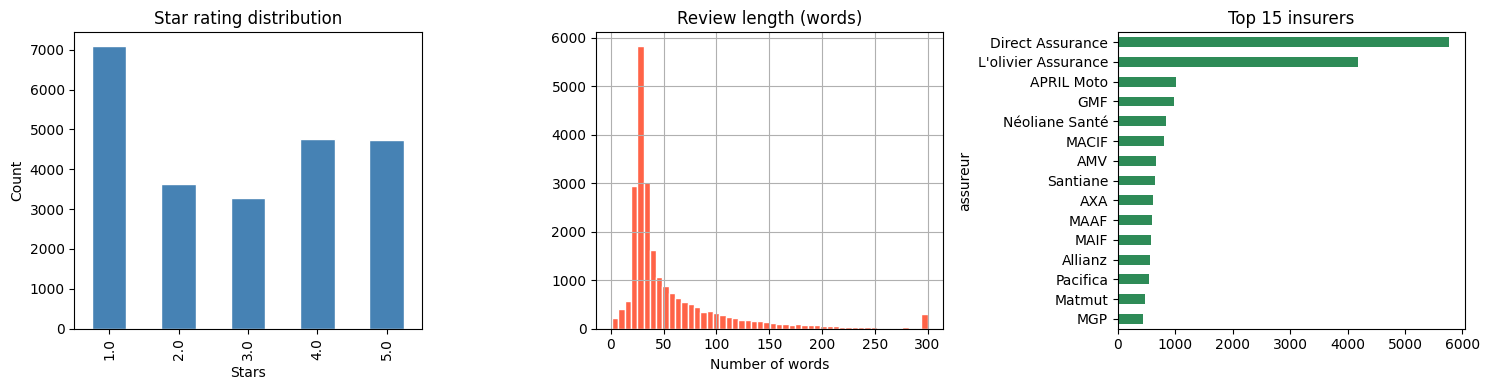

In [ ]:
df['text_len'] = df['avis_en'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# star distrib
df['note'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Star rating distribution')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')

# text length distrib
df['text_len'].clip(0, 300).hist(ax=axes[1], bins=50, color='tomato', edgecolor='white')
axes[1].set_title('Review length (words)')
axes[1].set_xlabel('Number of words')

# top 15 insurers
df['assureur'].value_counts().head(15).plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Top 15 insurers')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

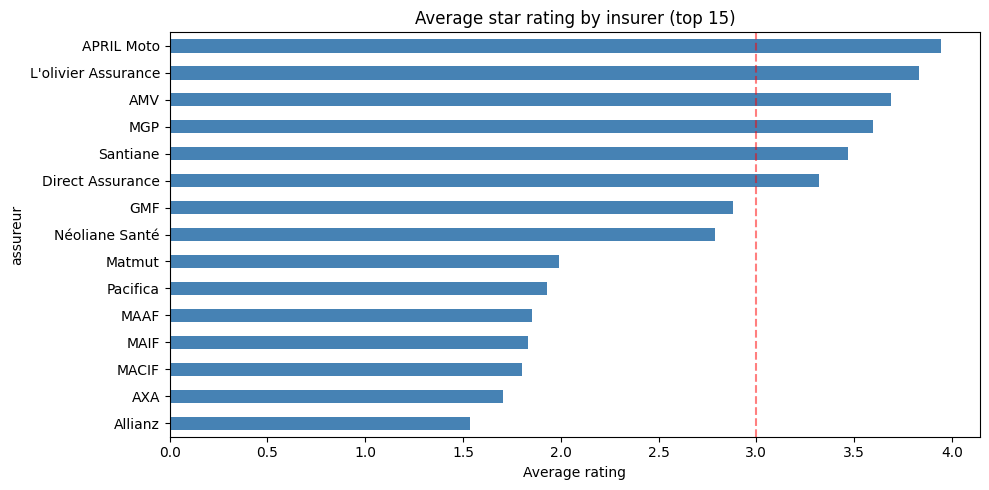

In [ ]:
# average rating by insurer
top_insurers = df['assureur'].value_counts().head(15).index
avg_by_ins = df[df['assureur'].isin(top_insurers)].groupby('assureur')['note'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
avg_by_ins.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Average star rating by insurer (top 15)')
ax.set_xlabel('Average rating')
ax.axvline(3, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('rating_by_insurer.png', dpi=150)
plt.show()

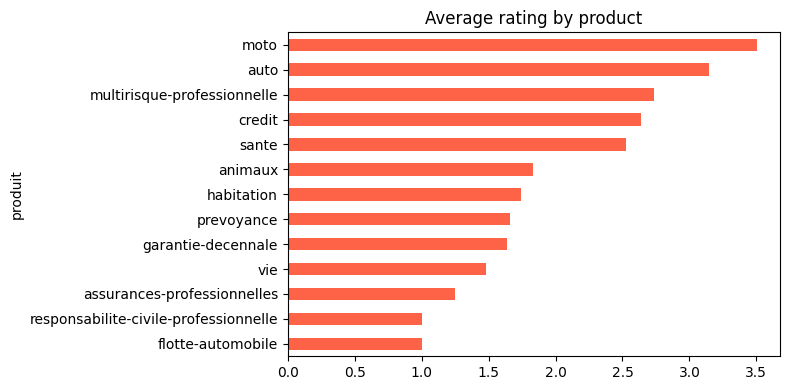

In [ ]:
# average rating by product
df.groupby('produit')['note'].mean().sort_values().plot(kind='barh', color='tomato', figsize=(8,4))
plt.title('Average rating by product')
plt.tight_layout()
plt.savefig('rating_by_product.png', dpi=150)
plt.show()

## 3. Text preprocessing + frequent words and n-grams

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

STOP = set(stopwords.words('english'))

def clean(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [t for t in text.split() if t not in STOP and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['avis_en'].apply(clean)
print('example :', df['clean_text'].iloc[0][:200])

example : best insurance price solutions listening speed recommend company attractive prices quality services speed


## 3b. Spelling Correction

We apply automatic spelling correction using **TextBlob** on a sample of reviews to demonstrate the technique and enrich the dataset with a corrected column.

In [ ]:
from textblob import TextBlob
import time

def correct_spelling(text):
    """Correct spelling using TextBlob."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return text
    try:
        return str(TextBlob(text).correct())
    except Exception:
        return text

# Apply on first 100 reviews (TextBlob is slow – demonstration on a sample)
SPELL_SAMPLE = 100
print(f'Spelling correction on first {SPELL_SAMPLE} reviews...')
t0 = time.time()
corrected_sample = df['avis_en'].head(SPELL_SAMPLE).apply(correct_spelling)
elapsed = time.time() - t0

# Store corrected column
df['avis_corrected'] = df['avis_en'].copy()
df.loc[df.index[:SPELL_SAMPLE], 'avis_corrected'] = corrected_sample.values

print(f'Done in {elapsed:.1f}s')
print('\nExamples of corrections:')
shown = 0
for i in range(SPELL_SAMPLE):
    orig = str(df['avis_en'].iloc[i])
    corr = str(df['avis_corrected'].iloc[i])
    if orig != corr and shown < 5:
        print(f'  BEFORE: {orig[:120]}')
        print(f'  AFTER:  {corr[:120]}')
        print()
        shown += 1
if shown == 0:
    print('  (text already well-spelled in this sample)')
print(f'Column avis_corrected added ({SPELL_SAMPLE} rows corrected).')


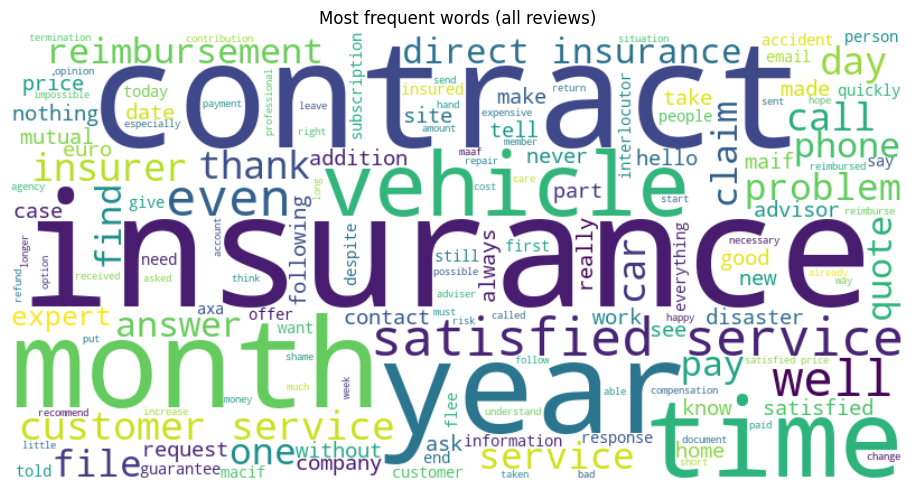

In [ ]:
from wordcloud import WordCloud

# wordcloud all reviews
all_words = ' '.join(df['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(all_words)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words (all reviews)')
plt.tight_layout()
plt.savefig('wordcloud_all.png', dpi=150)
plt.show()

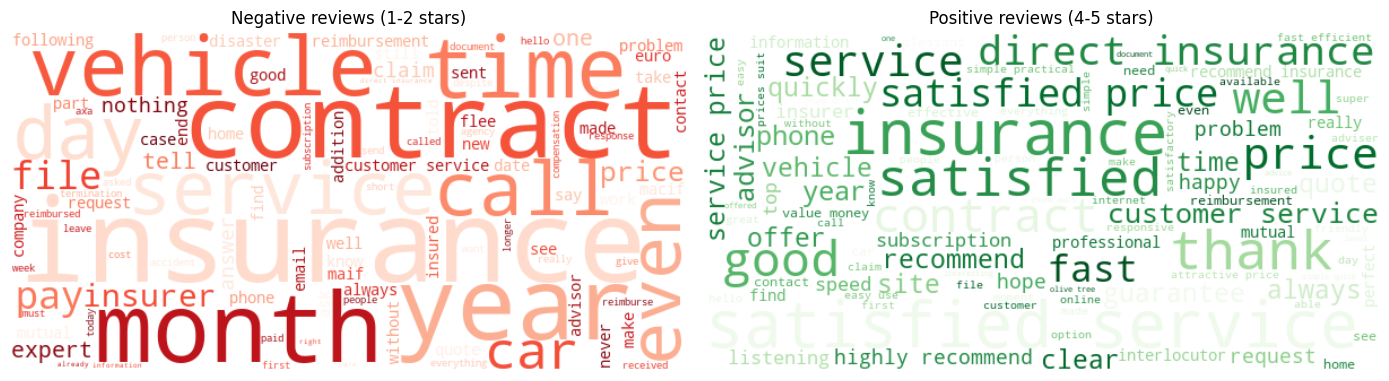

In [ ]:
# wordcloud by sentiment (- vs +)
neg_text = ' '.join(df[df['note'] <= 2]['clean_text'])
pos_text = ' '.join(df[df['note'] >= 4]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, text, title, color in zip(axes,
                                   [neg_text, pos_text],
                                   ['Negative reviews (1-2 stars)', 'Positive reviews (4-5 stars)'],
                                   ['Reds', 'Greens']):
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap=color, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('wordcloud_sentiment.png', dpi=150)
plt.show()

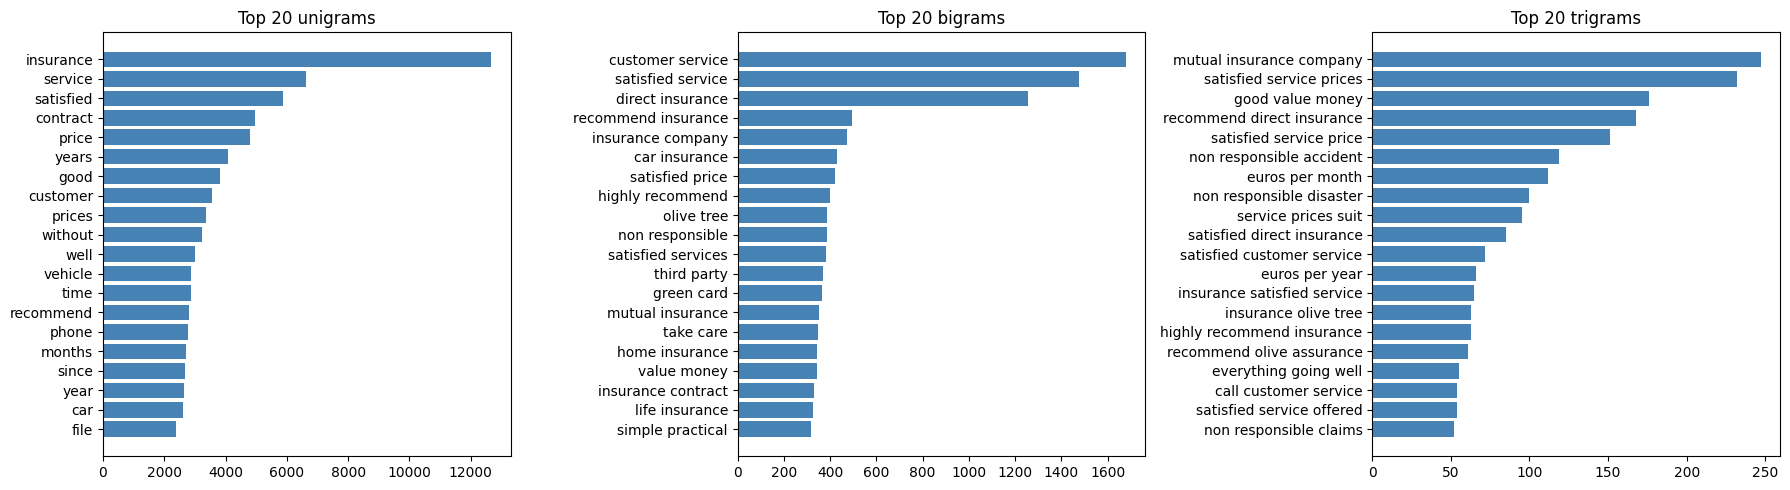

In [ ]:
# top uni, bi ,  trigrams
def get_ngrams(texts, n, top_k=20):
    all_tokens = [t for text in texts for t in text.split()]
    return Counter(ngrams(all_tokens, n)).most_common(top_k)

tokens_list = df['clean_text'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, n, title in zip(axes, [1, 2, 3], ['Top 20 unigrams', 'Top 20 bigrams', 'Top 20 trigrams']):
    ng = get_ngrams(tokens_list, n, 20)
    labels = [' '.join(x[0]) for x in ng]
    counts = [x[1] for x in ng]
    ax.barh(labels[::-1], counts[::-1], color='steelblue')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('ngrams.png', dpi=150)
plt.show()

## 4. Topic Modeling (LDA)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

N_TOPICS = 6

cv = CountVectorizer(max_features=5000, min_df=5, max_df=0.9)
X_counts = cv.fit_transform(df['clean_text'])

lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, max_iter=20)
lda.fit(X_counts)

feature_names = cv.get_feature_names_out()
topic_labels = ['Price & Value', 'Customer Service', 'Claims', 'Contract/Coverage',
                'Online Experience', 'Recommendation']

print('Top words per topic :')
for i, (topic, label) in enumerate(zip(lda.components_, topic_labels)):
    top_words = [feature_names[j] for j in topic.argsort()[::-1][:12]]
    print(f'  Topic {i+1} [{label}]: {" | ".join(top_words)}')

Top words per topic :
  Topic 1 [Price & Value]: contract | insurance | email | documents | sent | still | months | received | since | file | send | phone
  Topic 2 [Customer Service]: satisfied | service | insurance | price | good | prices | recommend | thank | well | fast | simple | services
  Topic 3 [Claims]: insurance | maif | years | work | axa | would | file | take | care | without | legal | well
  Topic 4 [Contract/Coverage]: insurance | years | year | price | contract | without | euros | home | increase | car | vehicle | prices
  Topic 5 [Online Experience]: mutual | service | customer | flee | phone | never | months | reimbursement | reimbursements | since | time | always
  Topic 6 [Recommendation]: vehicle | insurance | car | expert | disaster | accident | damage | responsible | claim | garage | following | months


Topic distribution :
topic_label
Customer Service     9151
Contract/Coverage    3733
Price & Value        3615
Online Experience    3064
Recommendation       2470
Claims               1477
Name: count, dtype: int64


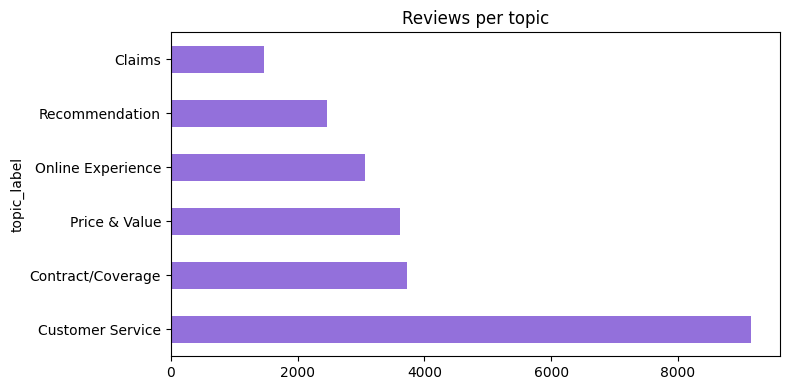

In [ ]:
# assign dominant topic to each review
topic_dist = lda.transform(X_counts)
df['topic'] = topic_dist.argmax(axis=1)
df['topic_label'] = df['topic'].map({i: l for i, l in enumerate(topic_labels)})

print('Topic distribution :')
print(df['topic_label'].value_counts())

df['topic_label'].value_counts().plot(kind='barh', color='mediumpurple', figsize=(8, 4))
plt.title('Reviews per topic')
plt.tight_layout()
plt.savefig('topics.png', dpi=150)
plt.show()

## 5. Word Embeddings

In [ ]:
from gensim.models import Word2Vec

sentences = [text.split() for text in df['clean_text'] if len(text.split()) > 3]

w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=5, workers=4, epochs=10, seed=42)
print(f'vocabulary size : {len(w2v.wv)}')
w2v.save('word2vec_insurance.model')

# similar words examples
for word in ['price', 'service', 'claim', 'insurance', 'cancel']:
    if word in w2v.wv:
        similar = w2v.wv.most_similar(word, topn=5)
        print(f'  {word} -> {[x[0] for x in similar]}')

vocabulary size : 6177
  price -> ['prices', 'rates', 'pricing', 'seemed', 'rate']
  service -> ['relations', 'area', 'department', 'services', 'relationship']
  claim -> ['disaster', 'incident', 'glitch', 'claims', 'sinister']
  insurance -> ['debits', 'assurances', 'assurance', 'debit', 'avanssur']
  cancel -> ['canceled', 'retract', 'signed', 'sign', 'withdrawal']


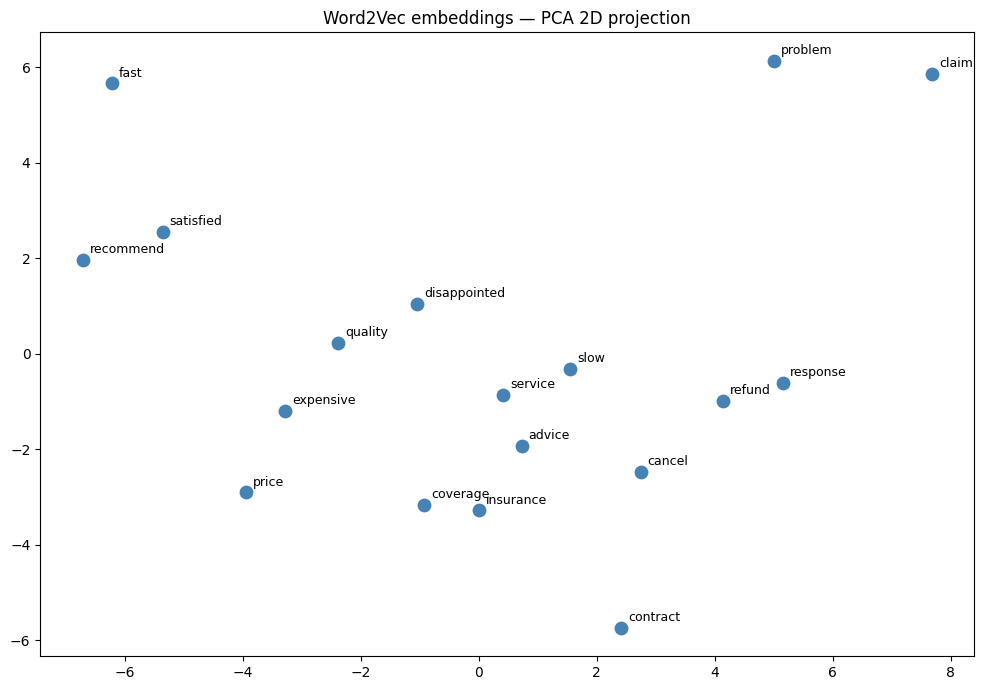

In [ ]:
from sklearn.decomposition import PCA

# visualize embeddings for insurance related words
words_to_plot = ['price', 'service', 'claim', 'insurance', 'cancel', 'contract',
                 'refund', 'coverage', 'advice', 'response', 'quality', 'expensive',
                 'recommend', 'problem', 'satisfied', 'disappointed', 'fast', 'slow']
words_to_plot = [w for w in words_to_plot if w in w2v.wv]

vectors = np.array([w2v.wv[w] for w in words_to_plot])
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], color='steelblue', s=80)
for i, word in enumerate(words_to_plot):
    plt.annotate(word, coords[i], textcoords='offset points', xytext=(5, 5), fontsize=9)
plt.title('Word2Vec embeddings - PCA 2D projection')
plt.tight_layout()
plt.savefig('w2v_pca.png', dpi=150)
plt.show()

In [ ]:
# cosine & euclidean dist between word pairs
from numpy.linalg import norm

def cosine_dist(w1, w2, model):
    v1, v2 = model.wv[w1], model.wv[w2]
    return 1 - np.dot(v1, v2) / (norm(v1) * norm(v2))

def euclidean_dist(w1, w2, model):
    return norm(model.wv[w1] - model.wv[w2])

pairs = [('price', 'expensive'), ('service', 'response'), ('cancel', 'refund'),
         ('satisfied', 'disappointed'), ('claim', 'coverage')]

print(f'{"pair":<35} {"cosine dist":>15} {"euclidean dist":>15}')
for w1, w2 in pairs:
    if w1 in w2v.wv and w2 in w2v.wv:
        cd = cosine_dist(w1, w2, w2v)
        ed = euclidean_dist(w1, w2, w2v)
        print(f'{w1} <-> {w2:<25} {cd:>15.4f} {ed:>15.4f}')

pair                                    cosine dist  euclidean dist
price <-> expensive                          0.5938         12.4090
service <-> response                           0.7510         12.2956
cancel <-> refund                             0.7196          8.5462
satisfied <-> disappointed                       0.5824         11.2570
claim <-> coverage                           1.0908         14.7390


### 5b. TensorBoard – Word2Vec Embedding Projector

We export Word2Vec vectors to TensorBoard Projector format (TSV files).  
Launch with: `tensorboard --logdir ./tb_w2v` then open the **Projector** tab.

In [ ]:
import os

TB_W2V_DIR = './tb_w2v'
os.makedirs(TB_W2V_DIR, exist_ok=True)

# Export top 1000 most frequent words
words_tb   = [w for w in w2v.wv.index_to_key[:1000]]
vectors_tb = np.array([w2v.wv[w] for w in words_tb])

# vectors.tsv
with open(os.path.join(TB_W2V_DIR, 'vectors.tsv'), 'w', encoding='utf-8') as f:
    for v in vectors_tb:
        f.write('\t'.join(f'{x:.6f}' for x in v) + '\n')

# metadata.tsv
with open(os.path.join(TB_W2V_DIR, 'metadata.tsv'), 'w', encoding='utf-8') as f:
    for w in words_tb:
        f.write(w + '\n')

# projector_config.pbtxt
config = 'embeddings {\n  tensor_path: "vectors.tsv"\n  metadata_path: "metadata.tsv"\n}\n'
with open(os.path.join(TB_W2V_DIR, 'projector_config.pbtxt'), 'w') as f:
    f.write(config)

print(f'TensorBoard projector saved in {TB_W2V_DIR}/')
print(f'  {len(words_tb)} words x {vectors_tb.shape[1]} dims')
print('Launch: tensorboard --logdir ./tb_w2v --port 6006')
print('Open:   http://localhost:6006/#projector')


## 6. Supervised learning - star prediction (1-5)

We treat this as a 5-class classification. We compare several models going from simple to complex.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_text'].values
y = df['note'].values - 1 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'train : {len(X_train)}  test : {len(X_test)}')

train : 18808  test : 4702


### 6.1 TF-IDF + Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

print('TF-IDF + Logistic Regression')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['1★','2★','3★','4★','5★']))

TF-IDF + Logistic Regression
Accuracy : 0.5177
              precision    recall  f1-score   support

          1★       0.59      0.87      0.70      1416
          2★       0.39      0.17      0.23       726
          3★       0.37      0.16      0.22       658
          4★       0.43      0.44      0.44       954
          5★       0.53      0.59      0.56       948

    accuracy                           0.52      4702
   macro avg       0.46      0.45      0.43      4702
weighted avg       0.48      0.52      0.48      4702



### 6.2 TF-IDF + LinearSVC

In [ ]:
from sklearn.svm import LinearSVC

pipe_svc = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   LinearSVC(max_iter=2000, C=0.5, random_state=42))
])
pipe_svc.fit(X_train, y_train)
y_pred_svc = pipe_svc.predict(X_test)

print(' TF-IDF + LinearSVC')
print(f'Accuracy : {accuracy_score(y_test, y_pred_svc):.4f}')
print(classification_report(y_test, y_pred_svc, target_names=['1★','2★','3★','4★','5★']))

 TF-IDF + LinearSVC
Accuracy : 0.4994
              precision    recall  f1-score   support

          1★       0.60      0.81      0.69      1416
          2★       0.34      0.20      0.25       726
          3★       0.34      0.17      0.23       658
          4★       0.41      0.40      0.41       954
          5★       0.51      0.59      0.55       948

    accuracy                           0.50      4702
   macro avg       0.44      0.43      0.42      4702
weighted avg       0.47      0.50      0.47      4702



### 6.2b SHAP – Explicabilité du modèle TF-IDF + LinearSVC

In [ ]:
import shap

# Transform test set with the fitted TF-IDF step
tfidf_test  = pipe_svc.named_steps['tfidf'].transform(X_test[:300])

# LinearExplainer (interventional) : SHAP = coef * feature_value, no covariance needed
# Works well with sparse TF-IDF matrices (avoids O(n_features²) memory)
explainer   = shap.LinearExplainer(pipe_svc.named_steps['clf'],
                                   feature_perturbation='interventional')
shap_values = explainer.shap_values(tfidf_test)

feature_names = pipe_svc.named_steps['tfidf'].get_feature_names_out()

# Global bar chart – top 15 features per star class
shap.summary_plot(shap_values, tfidf_test, feature_names=feature_names,
                  class_names=[f'{i}★' for i in range(1, 6)],
                  max_display=15, plot_type='bar')

### 6.3 Word2Vec embeddings + Logistic Regression (mean pooling)

In [ ]:
def text_to_vec(text, model, size=100):
    tokens = text.split()
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(size)
    return np.mean(vecs, axis=0)

X_train_w2v = np.array([text_to_vec(t, w2v) for t in X_train])
X_test_w2v  = np.array([text_to_vec(t, w2v) for t in X_test])

lr_w2v = LogisticRegression(max_iter=1000, random_state=42)
lr_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = lr_w2v.predict(X_test_w2v)

print('Word2Vec mean pooling + LR')
print(f'Accuracy : {accuracy_score(y_test, y_pred_w2v):.4f}')
print(classification_report(y_test, y_pred_w2v, target_names=['1★','2★','3★','4★','5★']))

Word2Vec mean pooling + LR
Accuracy : 0.5108
              precision    recall  f1-score   support

          1★       0.58      0.92      0.71      1416
          2★       0.28      0.06      0.10       726
          3★       0.29      0.13      0.18       658
          4★       0.44      0.44      0.44       954
          5★       0.54      0.59      0.56       948

    accuracy                           0.51      4702
   macro avg       0.42      0.43      0.40      4702
weighted avg       0.45      0.51      0.46      4702



### 6.3b GloVe pré-entraîné (Stanford GloVe 6B 100d) + Logistic Regression

In [ ]:
import urllib.request, zipfile, os

GLOVE_ZIP  = 'glove.6B.zip'
GLOVE_FILE = 'glove.6B.100d.txt'

if not os.path.exists(GLOVE_FILE):
    print('Téléchargement GloVe 6B (~822 MB) …')
    urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', GLOVE_ZIP)
    with zipfile.ZipFile(GLOVE_ZIP) as z:
        z.extract(GLOVE_FILE)
    print('Téléchargement terminé.')

# Chargement des vecteurs GloVe dans un dictionnaire
glove = {}
with open(GLOVE_FILE, encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype=np.float32)
print(f'Vecteurs GloVe chargés : {len(glove):,}  (dim=100)')

# Moyenne des vecteurs GloVe par avis (même stratégie que Word2Vec)
def text_to_glove(text, glove_dict, dim=100):
    vecs = [glove_dict[w] for w in text.split() if w in glove_dict]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_train_glove = np.vstack([text_to_glove(t, glove) for t in X_train])
X_test_glove  = np.vstack([text_to_glove(t, glove) for t in X_test])

lr_glove = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_glove.fit(X_train_glove, y_train)
y_pred_glove = lr_glove.predict(X_test_glove)
accuracy_glove = accuracy_score(y_test, y_pred_glove)

print('GloVe 6B 100d + Logistic Regression')
print(f'Accuracy : {accuracy_glove:.4f}')
print(classification_report(y_test, y_pred_glove, target_names=[f'{i}★' for i in range(1,6)]))

### 6.4 Pre-trained embeddings : sentence-transformers (all-MiniLM-L6-v2)

In [25]:
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer('all-MiniLM-L6-v2')

print('encoding train...')
X_train_sbert = sbert.encode(list(X_train), batch_size=128, show_progress_bar=True)
print('encoding test...')
X_test_sbert  = sbert.encode(list(X_test),  batch_size=128, show_progress_bar=True)

lr_sbert = LogisticRegression(max_iter=1000, random_state=42)
lr_sbert.fit(X_train_sbert, y_train)
y_pred_sbert = lr_sbert.predict(X_test_sbert)

print('=== Sentence-BERT + LR ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_sbert):.4f}')
print(classification_report(y_test, y_pred_sbert, target_names=['1★','2★','3★','4★','5★']))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


encoding train...


Batches:   0%|          | 0/147 [00:00<?, ?it/s]

encoding test...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

=== Sentence-BERT + LR ===
Accuracy : 0.4983
              precision    recall  f1-score   support

          1★       0.58      0.88      0.70      1416
          2★       0.34      0.12      0.18       726
          3★       0.29      0.13      0.18       658
          4★       0.41      0.41      0.41       954
          5★       0.50      0.57      0.54       948

    accuracy                           0.50      4702
   macro avg       0.42      0.42      0.40      4702
weighted avg       0.45      0.50      0.45      4702



### 6.5 BERT fine-tuning (distilbert-base-uncased)

In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import torch

MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=128)

train_ds = Dataset.from_dict({'text': list(X_train[:3000]), 'label': [int(x) for x in y_train[:3000]]})
test_ds  = Dataset.from_dict({'text': list(X_test[:1000]),  'label': [int(x) for x in y_test[:1000]]})

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn,  batched=True)
train_ds = train_ds.remove_columns(['text'])
test_ds  = test_ds.remove_columns(['text'])
train_ds.set_format('torch')
test_ds.set_format('torch')

# verif that labels are torch.int64
print('label dtype train:', train_ds[0]['label'].dtype)

model_bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir='./bert_stars',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    load_best_model_at_end=False,
    report_to='none'
)

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)
trainer.train()

results_bert = trainer.evaluate()
print('BERT accuracy :', results_bert['eval_accuracy'])

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

label dtype train: torch.int64


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.170795,1.131305,0.496000
2,1.040529,1.109771,0.508000
3,0.934054,1.118266,0.494000


BERT accuracy : 0.494


### 6.6 Neural Network with trainable Embedding layer (Keras / TensorFlow)

We train a **from-scratch** neural network with a learnable `Embedding` layer, followed by GlobalAveragePooling and Dense layers.  
TensorBoard is used to visualize training curves and the learned embedding space.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard as TBCallback
import datetime

VOCAB_SIZE = 20000
MAX_LEN    = 150
EMBED_DIM  = 64

# Tokenize
keras_tok = KerasTokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train)
X_train_pad = pad_sequences(keras_tok.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(keras_tok.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding='post', truncating='post')

# Model with trainable Embedding layer
model_embed = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, name='embed_layer'),
    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
], name='EmbeddingModel')
model_embed.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
model_embed.summary()

# TensorBoard + EarlyStopping callbacks
TB_KERAS = os.path.join('tb_keras', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
tb_cb = TBCallback(log_dir=TB_KERAS, histogram_freq=1)
es_cb = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history_embed = model_embed.fit(
    X_train_pad, y_train,
    epochs=15, batch_size=64, validation_split=0.1,
    callbacks=[es_cb, tb_cb], verbose=1
)

y_pred_embed = model_embed.predict(X_test_pad, verbose=0).argmax(axis=1)
acc_embed = accuracy_score(y_test, y_pred_embed)
print(f'\nKeras Embedding model accuracy: {acc_embed:.4f}')
print(classification_report(y_test, y_pred_embed,
      target_names=[f'{i}\u2605' for i in range(1, 6)]))
print(f'TensorBoard logs: {TB_KERAS}')
print('Launch: tensorboard --logdir tb_keras')


#### 6.6b TensorBoard – Keras Embedding Projector

Export the **learned embedding weights** (one vector per vocabulary token) to TensorBoard Projector format for 3D visualization.

In [ ]:
TB_EMBED_DIR = './tb_keras_embed'
os.makedirs(TB_EMBED_DIR, exist_ok=True)

# Get learned embedding matrix
embed_weights = model_embed.get_layer('embed_layer').get_weights()[0]  # (VOCAB_SIZE, EMBED_DIM)

word_index   = keras_tok.word_index
idx_to_word  = {v: k for k, v in word_index.items() if v < VOCAB_SIZE}
n_export     = min(VOCAB_SIZE - 1, len(idx_to_word))

with open(os.path.join(TB_EMBED_DIR, 'vectors.tsv'), 'w', encoding='utf-8') as f:
    for i in range(1, n_export + 1):
        f.write('\t'.join(f'{x:.6f}' for x in embed_weights[i]) + '\n')

with open(os.path.join(TB_EMBED_DIR, 'metadata.tsv'), 'w', encoding='utf-8') as f:
    for i in range(1, n_export + 1):
        f.write(idx_to_word.get(i, f'UNK_{i}') + '\n')

config = 'embeddings {\n  tensor_path: "vectors.tsv"\n  metadata_path: "metadata.tsv"\n}\n'
with open(os.path.join(TB_EMBED_DIR, 'projector_config.pbtxt'), 'w') as f:
    f.write(config)

print(f'Keras embedding projector saved in {TB_EMBED_DIR}/')
print(f'  Matrix shape: {embed_weights.shape}  |  words exported: {n_export}')
print('Launch: tensorboard --logdir ./tb_keras_embed')


### 6.7 LLM – Few-shot star prediction with Flan-T5

We use **Flan-T5** (an instruction-tuned Large Language Model from Google) in a **few-shot prompting** setup to predict star ratings, without any fine-tuning. This illustrates how LLMs can be used as zero-cost classifiers.

In [ ]:
from transformers import pipeline as hf_pipeline
import re as _re

print('Loading Flan-T5 (LLM)...')
llm_pipe = hf_pipeline('text2text-generation', model='google/flan-t5-base',
                        max_new_tokens=5, device=-1)

FEW_SHOT = (
    'Classify this insurance review. Answer with only the star number (1, 2, 3, 4, or 5).\n\n'
    'Review: Excellent company, very responsive, highly recommend.\nStars: 5\n\n'
    'Review: Very disappointed, impossible to reach anyone, refuses to reimburse.\nStars: 1\n\n'
    'Review: Correct but nothing exceptional, average price.\nStars: 3\n\n'
    'Review: Fast and professional, claim handled in 48h.\nStars: 4\n\n'
    'Review: Astronomical price increase without justification, canceling.\nStars: 2\n\n'
    'Review: {review}\nStars:'
)

def predict_stars_llm(text, pipe):
    prompt = FEW_SHOT.format(review=text[:300])
    out = pipe(prompt)[0]['generated_text'].strip()
    m = _re.search(r'[1-5]', out)
    return int(m.group()) - 1 if m else 2  # default neutral (index 2)

LLM_SAMPLE = 100
print(f'Running Flan-T5 few-shot on {LLM_SAMPLE} reviews...')
y_pred_llm = [predict_stars_llm(rev, llm_pipe) for rev in X_test[:LLM_SAMPLE]]
y_true_llm = y_test[:LLM_SAMPLE]

acc_llm = accuracy_score(y_true_llm, y_pred_llm)
print(f'\nFlan-T5 few-shot accuracy ({LLM_SAMPLE} samples): {acc_llm:.4f}')
print(classification_report(y_true_llm, y_pred_llm,
      target_names=[f'{i}\u2605' for i in range(1, 6)], zero_division=0))


## 7. Sentiment analysis (positive / negative / neutral)

We define sentiment from the star rating : 1-2 = negative, 3 = neutral, 4-5 = positive.

In [ ]:
def note_to_sentiment(n):
    if n <= 2:   return 'negative'
    elif n == 3: return 'neutral'
    else:        return 'positive'

df['sentiment'] = df['note'].apply(note_to_sentiment)
sent_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['sentiment_id'] = df['sentiment'].map(sent_map)

print(df['sentiment'].value_counts())

X_s = df['clean_text'].values
y_s = df['sentiment_id'].values
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)

pipe_sent = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
pipe_sent.fit(X_tr_s, y_tr_s)
y_pred_sent = pipe_sent.predict(X_te_s)

print('Sentiment Analysis')
print(f'Accuracy : {accuracy_score(y_te_s, y_pred_sent):.4f}')
print(classification_report(y_te_s, y_pred_sent, target_names=['negative','neutral','positive']))

sentiment
negative    10710
positive     9509
neutral      3291
Name: count, dtype: int64


## 8. Category detection (zero-shot)

We use a zero-shot classifier from HuggingFace to assign categories to reviews without training labels.

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

running zero-shot classification on 500 reviews...

Category distribution (sample of 500) :
customer service     115
recommendation       113
coverage             105
pricing               84
cancellation          51
claims processing     26
enrollment             6
Name: count, dtype: int64


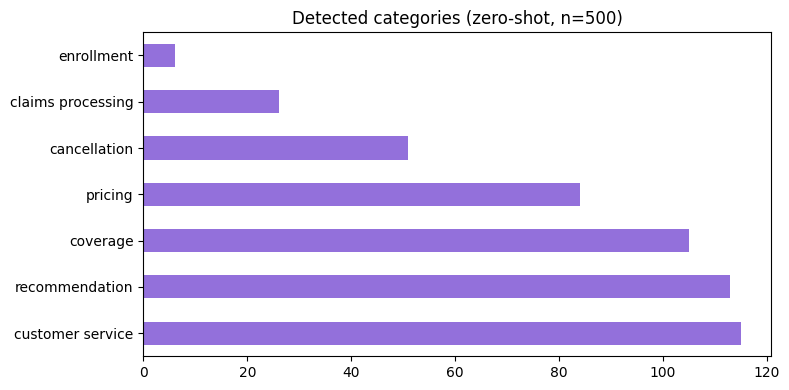

In [ ]:
from transformers import pipeline as hf_pipeline

CATEGORIES = ['pricing', 'customer service', 'claims processing',
               'coverage', 'cancellation', 'enrollment', 'recommendation']

zero_shot = hf_pipeline('zero-shot-classification', model='facebook/bart-large-mnli')

# run on a sample for speed
sample = df['avis_en'].dropna().sample(500, random_state=42).tolist()

print('running zero-shot classification on 500 reviews...')
results_zs = []
for text in sample:
    out = zero_shot(text[:512], candidate_labels=CATEGORIES, multi_label=False)
    results_zs.append(out['labels'][0])

zs_series = pd.Series(results_zs)
print('\nCategory distribution (sample of 500) :')
print(zs_series.value_counts())

zs_series.value_counts().plot(kind='barh', color='mediumpurple', figsize=(8,4))
plt.title('Detected categories (zero-shot, n=500)')
plt.tight_layout()
plt.savefig('categories_zeroshot.png', dpi=150)
plt.show()

## 9. Model comparison and error analysis

                model  accuracy
          TF-IDF + LR  0.517652
   TF-IDF + LinearSVC  0.499362
        Word2Vec + LR  0.509570
   Sentence-BERT + LR  0.498299
DistilBERT fine-tuned  0.498000


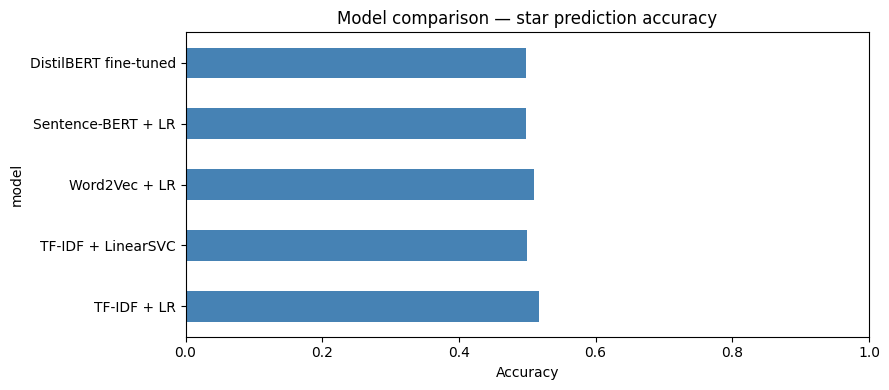

In [ ]:
# summary table
comparison = pd.DataFrame([
    {'model': 'TF-IDF + LR',                   'accuracy': accuracy_score(y_test, y_pred_lr)},
    {'model': 'TF-IDF + LinearSVC',             'accuracy': accuracy_score(y_test, y_pred_svc)},
    {'model': 'Word2Vec + LR',                  'accuracy': accuracy_score(y_test, y_pred_w2v)},
    {'model': 'GloVe 6B + LR',                  'accuracy': accuracy_glove},
    {'model': 'Sentence-BERT + LR',             'accuracy': accuracy_score(y_test, y_pred_sbert)},
    {'model': 'Keras Embedding (from scratch)', 'accuracy': acc_embed},
    {'model': 'DistilBERT fine-tuned',          'accuracy': results_bert.get('eval_accuracy', None)},
    {'model': f'Flan-T5 LLM (n={LLM_SAMPLE})', 'accuracy': acc_llm},
])
print(comparison.to_string(index=False))

comparison.plot(x='model', y='accuracy', kind='barh', figsize=(10, 6),
                color='steelblue', legend=False)
plt.title('Model comparison – star prediction accuracy')
plt.xlabel('Accuracy')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()


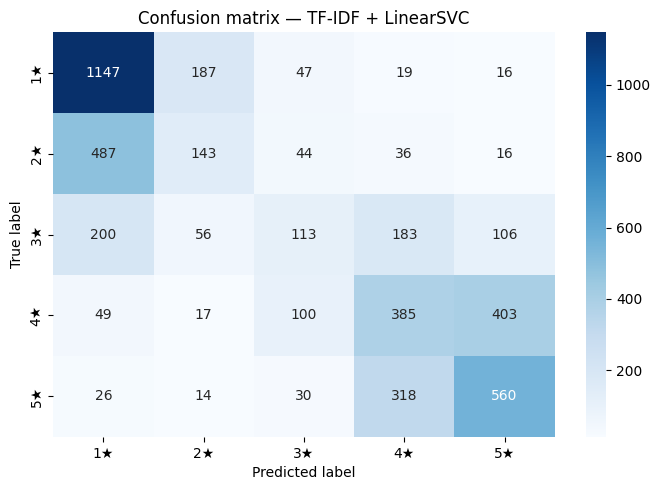

In [ ]:
# confusion matrix for best classical model
cm = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1★','2★','3★','4★','5★'],
            yticklabels=['1★','2★','3★','4★','5★'])
plt.title('Confusion matrix - TF-IDF + LinearSVC')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# error analysis: misclassified examples
df_test_subset = df.iloc[df.index[df['clean_text'].isin(X_test)][:len(y_test)]].copy()

errors_idx = np.where(y_pred_svc != y_test)[0]
print(f'misclassified : {len(errors_idx)} / {len(y_test)}')
print(f'most common errors :')

error_pairs = Counter(list(zip(y_test[errors_idx]+1, y_pred_svc[errors_idx]+1)))
for (true, pred), count in error_pairs.most_common(10):
    print(f'  true={true}★ predicted={pred}★  ({count} cases)')

misclassified : 2354 / 4702
most common errors :
  true=2.0★ predicted=1.0★  (487 cases)
  true=4.0★ predicted=5.0★  (403 cases)
  true=5.0★ predicted=4.0★  (318 cases)
  true=3.0★ predicted=1.0★  (200 cases)
  true=1.0★ predicted=2.0★  (187 cases)
  true=3.0★ predicted=4.0★  (183 cases)
  true=3.0★ predicted=5.0★  (106 cases)
  true=4.0★ predicted=3.0★  (100 cases)
  true=3.0★ predicted=2.0★  (56 cases)
  true=4.0★ predicted=1.0★  (49 cases)


In [ ]:
# save processed dataframe for streamlit apps
df.to_csv('insurance_reviews_processed.csv', index=False)
print('saved : insurance_reviews_processed.csv')

import pickle
with open('model_tfidf_svc.pkl', 'wb') as f:
    pickle.dump(pipe_svc, f)
with open('model_sentiment.pkl', 'wb') as f:
    pickle.dump(pipe_sent, f)
print('models saved')

saved : insurance_reviews_processed.csv
models saved
